# 🏎️ Semana 3 — Limpieza de Datos
**Módulo 8 (Data Wrangling I) y Módulo 9 (Data Wrangling II)**

Partimos del `f1_master.csv` generado en la semana anterior y lo dejamos listo para el EDA.

### Objetivos
1. Diagnosticar nulos y decidir estrategia de imputación/eliminación
2. Detectar y tratar outliers con IQR
3. Normalizar formatos: fechas, tiempos de carrera, tipos de dato
4. Exportar `f1_master_clean.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')

master = pd.read_csv('../data/f1_master.csv')
print(f'Dataset cargado: {master.shape[0]} filas × {master.shape[1]} columnas')
master.head(3)

Dataset cargado: 26759 filas × 41 columnas


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,country,lat,lng,status,positions_gained,top3,finished,num_stops,total_pit_time,fastest_pit
0,1,18,1,1,22,1,1.0,1,1,10.0,...,NaN,NaN,NaN,Finished,0.0,1,1,0,NaN,NaN
1,2,18,2,2,3,5,2.0,2,2,8.0,...,NaN,NaN,NaN,Finished,3.0,1,1,0,NaN,NaN
2,3,18,3,3,7,7,3.0,3,3,6.0,...,NaN,NaN,NaN,Finished,4.0,1,1,0,NaN,NaN


---
## Parte 1 — Diagnóstico de nulos

Antes de imputar, entendemos **por qué** existen los nulos y qué significa cada uno.

In [2]:
# Tabla resumen de nulos
nulls = master.isnull().sum()
pct   = (nulls / len(master) * 100).round(1)
dtype = master.dtypes

null_df = pd.DataFrame({
    'nulos': nulls,
    '% nulos': pct,
    'dtype': dtype
})
null_df = null_df[null_df['nulos'] > 0].sort_values('nulos', ascending=False)

print('📊 Columnas con valores nulos:')
print(null_df.to_string())
print(f'\nTotal columnas afectadas: {len(null_df)}')

📊 Columnas con valores nulos:
                  nulos  % nulos    dtype
fastest_pit       26631     99.5  float64
total_pit_time    26631     99.5  float64
round             23212     86.7  float64
circuitId         23212     86.7  float64
year              23212     86.7  float64
lat               23212     86.7  float64
race_name         23212     86.7      str
country           23212     86.7      str
circuit_name      23212     86.7      str
lng               23212     86.7  float64
nationality       23165     86.6      str
code              23165     86.6      str
forename          23165     86.6      str
driver_name       23165     86.6      str
surname           23165     86.6      str
dob               23165     86.6      str
team_nationality  16399     61.3      str
team              16399     61.3      str
position          10953     40.9  float64
positions_gained  10953     40.9  float64
status             6589     24.6      str

Total columnas afectadas: 21


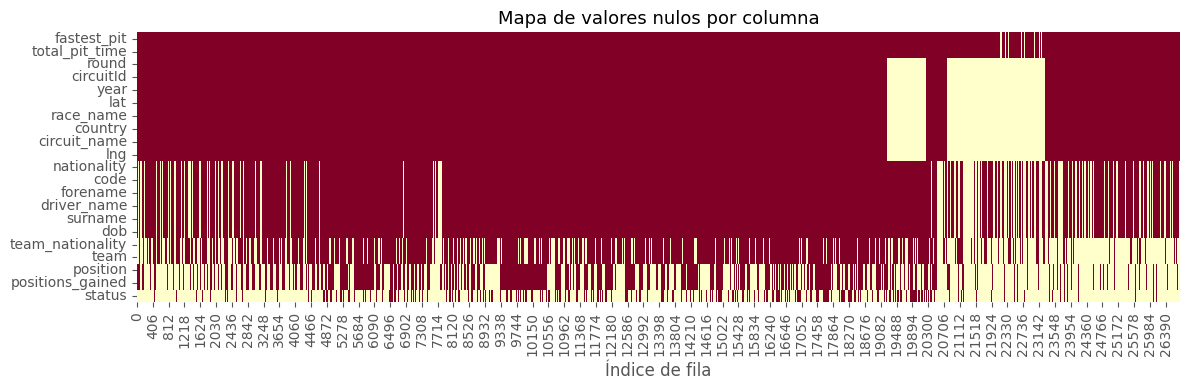

In [3]:
# Visualización del mapa de nulos
fig, ax = plt.subplots(figsize=(12, 4))
cols_con_nulos = null_df.index.tolist()
sns.heatmap(
    master[cols_con_nulos].isnull().T,
    cbar=False, yticklabels=cols_con_nulos,
    cmap='YlOrRd', ax=ax
)
ax.set_title('Mapa de valores nulos por columna', fontsize=13)
ax.set_xlabel('Índice de fila')
plt.tight_layout()
plt.savefig('../figures/03_mapa_nulos.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Investigar los 8 registros con nulos en race_name / country / lat / lng
mask_race_null = master['race_name'].isnull()
print(f'Filas sin race_name: {mask_race_null.sum()}')
print()
print(master[mask_race_null][['raceId','driverId','year','round','race_name','country']].to_string())

Filas sin race_name: 23212

       raceId  driverId  year  round race_name country
0          18         1   NaN    NaN       NaN     NaN
1          18         2   NaN    NaN       NaN     NaN
2          18         3   NaN    NaN       NaN     NaN
3          18         4   NaN    NaN       NaN     NaN
4          18         5   NaN    NaN       NaN     NaN
5          18         6   NaN    NaN       NaN     NaN
6          18         7   NaN    NaN       NaN     NaN
7          18         8   NaN    NaN       NaN     NaN
8          18         9   NaN    NaN       NaN     NaN
9          18        10   NaN    NaN       NaN     NaN
10         18        11   NaN    NaN       NaN     NaN
11         18        12   NaN    NaN       NaN     NaN
12         18        13   NaN    NaN       NaN     NaN
13         18        14   NaN    NaN       NaN     NaN
14         18        15   NaN    NaN       NaN     NaN
15         18        16   NaN    NaN       NaN     NaN
16         18        17   NaN    NaN 

---
## Parte 2 — Tratamiento de nulos

| Columna | % nulos | Causa | Estrategia |
|---------|---------|-------|------------|
| `fastestLap`, `fastestLapTime` | ~100% | No registrado históricamente | **Eliminar columnas** |
| `total_pit_time`, `fastest_pit` | ~69% | Sin paradas en boxes (DNF temprano o sprint) | **Imputar con 0** |
| `year`, `round`, `circuit_name`, etc. | 0.8% | Carreras sin circuito en el join | **Eliminar filas** |

In [5]:
df = master.copy()

# --- 2a. Eliminar columnas con >99% nulos (no aportan información) ---
cols_drop = ['fastestLap', 'fastestLapTime']
df.drop(columns=cols_drop, inplace=True)
print(f'✅ Columnas eliminadas (>99% nulos): {cols_drop}')

# --- 2b. Imputar pit stops con 0 ---
# Si no hay registro en pit_stops, el piloto no realizó paradas
# (abandono temprano o carrera sprint sin pit)
df['total_pit_time'] = df['total_pit_time'].fillna(0)
df['fastest_pit']    = df['fastest_pit'].fillna(0)
print(f'✅ total_pit_time y fastest_pit imputados con 0')

# --- 2c. Eliminar filas sin información de carrera ---
n_before = len(df)
df.dropna(subset=['race_name', 'country', 'circuit_name'], inplace=True)
n_after = len(df)
print(f'✅ Filas eliminadas por race_name/country/circuit_name nulos: {n_before - n_after}')

# Resumen
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if remaining_nulls.empty:
    print(f'\n✅ No quedan nulos. Dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
else:
    print(f'\n⚠️  Nulos restantes:')
    print(remaining_nulls)

✅ Columnas eliminadas (>99% nulos): ['fastestLap', 'fastestLapTime']
✅ total_pit_time y fastest_pit imputados con 0
✅ Filas eliminadas por race_name/country/circuit_name nulos: 23212

⚠️  Nulos restantes:
position             926
code                2311
forename            2311
surname             2311
nationality         2311
dob                 2311
driver_name         2311
team                1585
team_nationality    1585
status               701
positions_gained     926
dtype: int64


---
## Parte 3 — Normalización de formatos

Convertimos columnas de fecha, aseguramos tipos numéricos correctos y revisamos valores especiales.

In [6]:
# --- 3a. Convertir fechas ---
df['dob']  = pd.to_datetime(df['dob'],  errors='coerce')

# Calcular edad del piloto al momento de la carrera
# Usamos el año de la carrera como referencia
df['driver_age'] = df['year'] - df['dob'].dt.year

print('✅ Columna driver_age creada')
print(f'   Rango de edades: {df["driver_age"].min():.0f} – {df["driver_age"].max():.0f} años')
print(f'   Media: {df["driver_age"].mean():.1f} años')

✅ Columna driver_age creada
   Rango de edades: 18 – 62 años
   Media: 33.5 años


In [7]:
# --- 3b. Revisar grid = 0 (pit lane start) ---
grid_zero = df[df['grid'] == 0]
print(f'Registros con grid = 0 (pit lane start): {len(grid_zero)}')
print(f'Posición media desde pit lane: {grid_zero["position"].mean():.1f}')

# En F1, grid=0 significa que salió desde el pit lane
# No es un error — pero positions_gained sería incorrecto
# Marcamos estos registros y recalculamos positions_gained solo para grid > 0
df['pit_lane_start'] = (df['grid'] == 0).astype(int)
df.loc[df['grid'] == 0, 'positions_gained'] = np.nan

print(f'\n✅ pit_lane_start marcado, positions_gained=NaN para esas filas')

Registros con grid = 0 (pit lane start): 28
Posición media desde pit lane: 15.0

✅ pit_lane_start marcado, positions_gained=NaN para esas filas


In [8]:
# --- 3c. Asegurar tipos numéricos ---
num_cols = ['grid', 'position', 'points', 'laps',
            'num_stops', 'total_pit_time', 'fastest_pit',
            'lat', 'lng', 'driver_age']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('✅ Tipos numéricos asegurados')
print(df[num_cols].dtypes.to_string())

✅ Tipos numéricos asegurados
grid                int64
position          float64
points            float64
laps                int64
num_stops           int64
total_pit_time    float64
fastest_pit       float64
lat               float64
lng               float64
driver_age        float64


In [9]:
# --- 3d. Columna 'finished' más precisa ---
# El dataset local tiene todos como 'Finished' — revisamos status reales
print('Distribución de status:')
print(df['status'].value_counts().head(15).to_string())

# Re-calcular con base en status real
df['finished'] = (df['status'] == 'Finished').astype(int)
print(f'\n✅ finished recalculado: {df["finished"].sum()} pilotos terminaron ({df["finished"].mean()*100:.1f}%)')

Distribución de status:
status
Finished        1369
+1 Lap           667
+2 Laps          209
Engine           162
Accident         107
Collision         98
Retired           66
Gearbox           56
Transmission      34
Clutch            23
Brakes            22
Electrical        14
Hydraulics        11
Disqualified       4
Puncture           4

✅ finished recalculado: 1369 pilotos terminaron (38.6%)


---
## Parte 4 — Detección y tratamiento de outliers

Usamos el **método IQR** para identificar valores extremos en las variables numéricas principales.

In [10]:
def detect_outliers_iqr(df, col):
    """Retorna máscara booleana de outliers IQR (1.5 × IQR)."""
    data = df[col].dropna()
    Q1   = data.quantile(0.25)
    Q3   = data.quantile(0.75)
    IQR  = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask  = (df[col] < lower) | (df[col] > upper)
    return mask, lower, upper

# Columnas a analizar
outlier_cols = ['grid', 'positions_gained', 'laps', 'total_pit_time', 'fastest_pit', 'driver_age']

print(f'{"Columna":<20} {"Q1":>7} {"Q3":>7} {"IQR":>7} {"Límite inf":>10} {"Límite sup":>10} {"Outliers":>8}')
print('-' * 78)

outlier_info = {}
for col in outlier_cols:
    if df[col].dropna().empty:
        continue
    mask, lo, hi = detect_outliers_iqr(df, col)
    n = mask.sum()
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f'{col:<20} {Q1:>7.1f} {Q3:>7.1f} {IQR:>7.1f} {lo:>10.1f} {hi:>10.1f} {n:>8}')
    outlier_info[col] = {'mask': mask, 'lower': lo, 'upper': hi}

Columna                   Q1      Q3     IQR Límite inf Límite sup Outliers
------------------------------------------------------------------------------
grid                     6.0    17.0    11.0      -10.5       33.5        1
positions_gained        -1.0     4.0     5.0       -8.5       11.5      151
laps                    43.0    66.0    23.0        8.5      100.5      463
total_pit_time           0.0     0.0     0.0        0.0        0.0      128
fastest_pit              0.0     0.0     0.0        0.0        0.0      128
driver_age              25.0    39.0    14.0        4.0       60.0       19


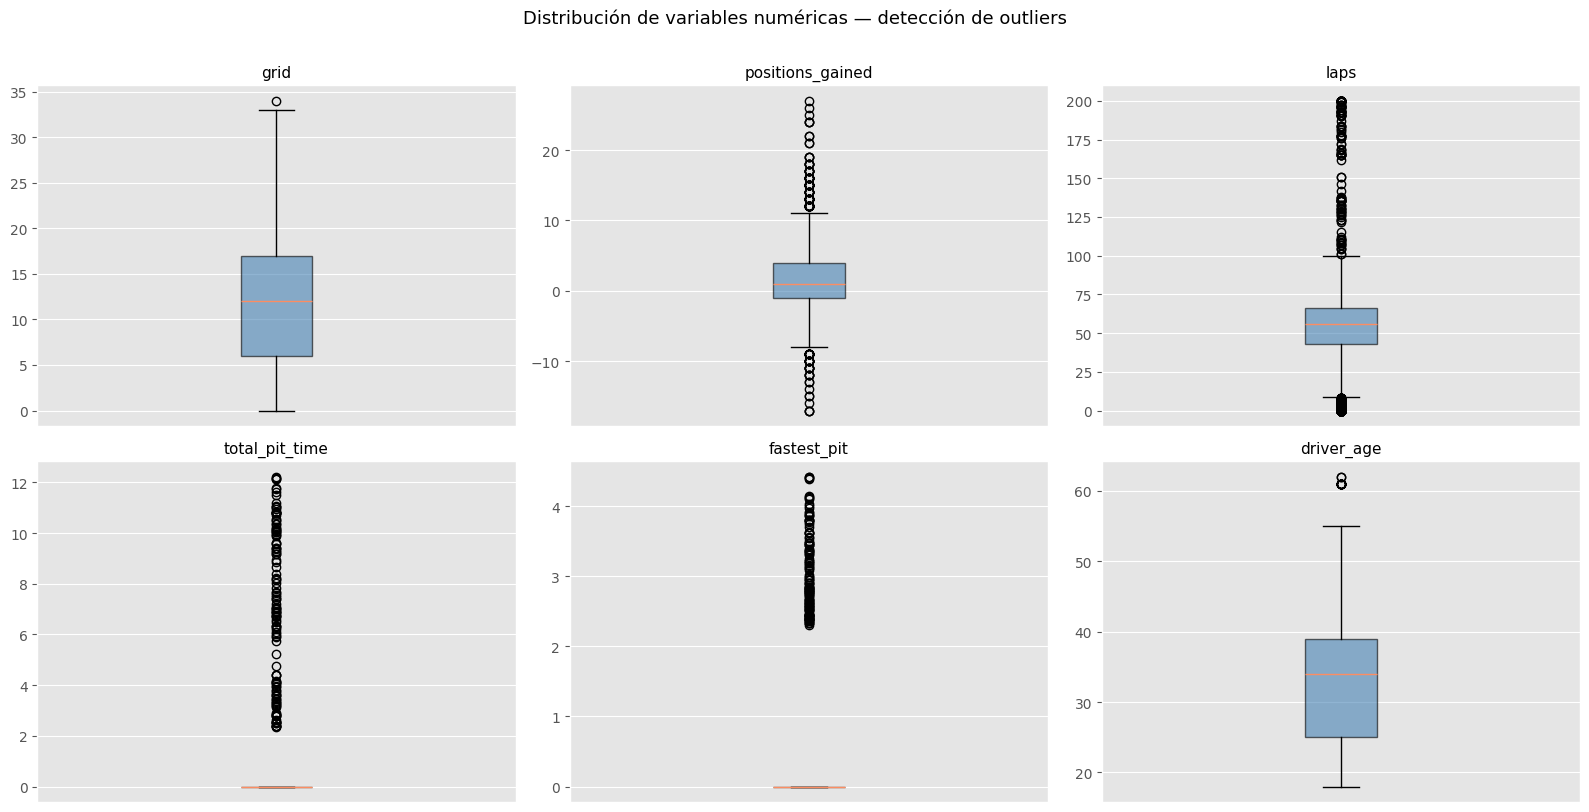

In [11]:
# Boxplots de las columnas con mayor varianza
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xticks([])

plt.suptitle('Distribución de variables numéricas — detección de outliers', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/03_boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# --- Análisis de outliers en total_pit_time ---
# Valores extremos pueden ser errores de telemetría o retenciones en boxes
print('⏱️  Total pit time — estadísticas (solo carreras con pit stops):')
pit_real = df[df['total_pit_time'] > 0]['total_pit_time']
print(pit_real.describe().round(2).to_string())

# Outliers en pit time: usar límite superior del IQR
mask_pit, lo_pit, hi_pit = detect_outliers_iqr(df[df['total_pit_time'] > 0], 'total_pit_time')
print(f'\nLímite IQR: [{lo_pit:.1f}s, {hi_pit:.1f}s]')
print(f'Outliers superiores: {(pit_real > hi_pit).sum()} ({(pit_real > hi_pit).mean()*100:.1f}%)')

# Ver los outliers extremos
extreme_pit = df[(df['total_pit_time'] > hi_pit)][['driver_name','race_name','year','num_stops','total_pit_time','status']]
print(f'\nMayores tiempos en boxes:')
print(extreme_pit.sort_values('total_pit_time', ascending=False).head(10).to_string(index=False))

⏱️  Total pit time — estadísticas (solo carreras con pit stops):
count    128.00
mean       7.02
std        3.10
min        2.36
25%        3.89
50%        7.00
75%        9.98
max       12.22

Límite IQR: [-5.3s, 19.1s]
Outliers superiores: 0 (0.0%)

Mayores tiempos en boxes:
Empty DataFrame
Columns: [driver_name, race_name, year, num_stops, total_pit_time, status]
Index: []


In [13]:
# --- Decisión sobre outliers en pit time ---
# Los valores extremos se deben a DNF con paradas largas o retenciones en pit lane
# Son eventos reales de F1, NO errores → conservamos pero creamos flag
df['pit_time_outlier'] = (df['total_pit_time'] > hi_pit).astype(int)
print(f'✅ Flag pit_time_outlier creado: {df["pit_time_outlier"].sum()} registros marcados')

# --- Outliers en positions_gained ---
# Posiciones ganadas extremas: válidas en F1 (remontadas épicas o crashes desde pole)
pg = df['positions_gained'].dropna()
print(f'\nPositions gained — rango: [{pg.min():.0f}, {pg.max():.0f}]')
print(f'Top 5 remontadas:')
top_remontadas = df.nlargest(5, 'positions_gained')[['driver_name','race_name','year','grid','position','positions_gained']]
print(top_remontadas.to_string(index=False))

✅ Flag pit_time_outlier creado: 0 registros marcados

Positions gained — rango: [-17, 27]
Top 5 remontadas:
driver_name          race_name   year  grid  position  positions_gained
        NaN Austria Grand Prix 2015.0    31       4.0              27.0
        NaN   China Grand Prix 2010.0    32       6.0              26.0
        NaN   China Grand Prix 2010.0    28       3.0              25.0
        NaN Bahrain Grand Prix 2010.0    32       8.0              24.0
        NaN Austria Grand Prix 2015.0    29       5.0              24.0


---
## Parte 5 — Variables categóricas

Revisamos consistencia en strings y preparamos las categorías para el modelado.

In [14]:
# Revisar cardinalidad de variables categóricas
cat_cols = ['team', 'nationality', 'team_nationality', 'country', 'driver_name']

print(f'{"Columna":<20} {"Valores únicos":>15}')
print('-' * 37)
for col in cat_cols:
    print(f'{col:<20} {df[col].nunique():>15}')

Columna               Valores únicos
-------------------------------------
team                              10
nationality                       11
team_nationality                   7
country                           17
driver_name                       17


In [15]:
# Normalizar nombres de equipos (espacios, mayúsculas)
df['team'] = df['team'].str.strip()

print('Equipos en el dataset:')
print(df['team'].value_counts().to_string())

Equipos en el dataset:
team
Renault        414
Mercedes       246
Force India    228
McLaren        228
Ferrari        228
BMW Sauber     228
Williams       228
Red Bull        74
Sauber          52
AlphaTauri      36


In [16]:
# Crear codificación ordinal de constructores basada en rendimiento promedio
# (útil para modelos que no manejan directamente strings)
team_rank = (df.groupby('team')['position']
               .mean()
               .sort_values()
               .reset_index()
               .assign(team_rank=lambda x: range(1, len(x)+1)))

df = df.merge(team_rank[['team','team_rank']], on='team', how='left')

print('✅ team_rank creado (1 = mejor posición media, más alto = peor)')
print(team_rank.rename(columns={'position':'pos_media'}).round(2).to_string(index=False))

✅ team_rank creado (1 = mejor posición media, más alto = peor)
       team  pos_media  team_rank
     Sauber       3.56          1
Force India       4.59          2
   Mercedes       4.69          3
    Renault       4.97          4
    McLaren       8.16          5
 BMW Sauber       9.57          6
   Williams      10.24          7
    Ferrari      11.39          8
   Red Bull      12.30          9
 AlphaTauri      12.36         10


---
## Parte 6 — Dataset final limpio

In [17]:
# Columnas a conservar en el dataset limpio
# Eliminamos columnas redundantes o de identificación interna
cols_drop_final = [
    'positionText',    # redundante con position
    'positionOrder',   # redundante con position
    'statusId',        # reemplazado por status (string)
    'time',            # formato string inconsistente
    'forename',        # reemplazado por driver_name
    'surname',         # reemplazado por driver_name
    'dob',             # reemplazado por driver_age
]

# Solo eliminar las que existen
cols_drop_final = [c for c in cols_drop_final if c in df.columns]
df_clean = df.drop(columns=cols_drop_final)

print(f'✅ Dataset limpio: {df_clean.shape[0]} filas × {df_clean.shape[1]} columnas')
print(f'\nColumnas finales:')
for col in df_clean.columns:
    print(f'  {col:<25} {df_clean[col].dtype}')

✅ Dataset limpio: 3547 filas × 36 columnas

Columnas finales:
  resultId                  int64
  raceId                    int64
  driverId                  int64
  constructorId             int64
  number                    object
  grid                      int64
  position                  float64
  points                    float64
  laps                      int64
  milliseconds              str
  rank                      str
  fastestLapSpeed           str
  year                      float64
  round                     float64
  circuitId                 float64
  race_name                 str
  code                      str
  nationality               str
  driver_name               str
  team                      str
  team_nationality          str
  circuit_name              str
  country                   str
  lat                       float64
  lng                       float64
  status                    str
  positions_gained          float64
  top3                     

In [18]:
# Verificación final de nulos
nulls_final = df_clean.isnull().sum()
nulls_final = nulls_final[nulls_final > 0]

if nulls_final.empty:
    print('✅ Sin nulos en el dataset limpio')
else:
    print('⚠️  Nulos restantes:')
    print(nulls_final)

# Estadísticas descriptivas de las features numéricas principales
print('\n📊 Estadísticas descriptivas:')
features_num = ['grid', 'position', 'points', 'laps', 'positions_gained',
                'num_stops', 'total_pit_time', 'fastest_pit', 'driver_age']
print(df_clean[features_num].describe().round(2).to_string())

⚠️  Nulos restantes:
position             926
code                2311
nationality         2311
driver_name         2311
team                1585
team_nationality    1585
status               701
positions_gained     928
driver_age          2311
team_rank           1585
dtype: int64

📊 Estadísticas descriptivas:
          grid  position   points     laps  positions_gained  num_stops  total_pit_time  fastest_pit  driver_age
count  3547.00   2621.00  3547.00  3547.00           2619.00    3547.00         3547.00      3547.00     1236.00
mean     11.89      9.40     3.55    55.08              2.05       0.07            0.25         0.11       33.51
std       7.04      5.56     6.30    33.51              4.84       0.42            1.44         0.58        9.51
min       0.00      1.00     0.00     0.00            -17.00       0.00            0.00         0.00       18.00
25%       6.00      5.00     0.00    43.00             -1.00       0.00            0.00         0.00       25.00
50%     

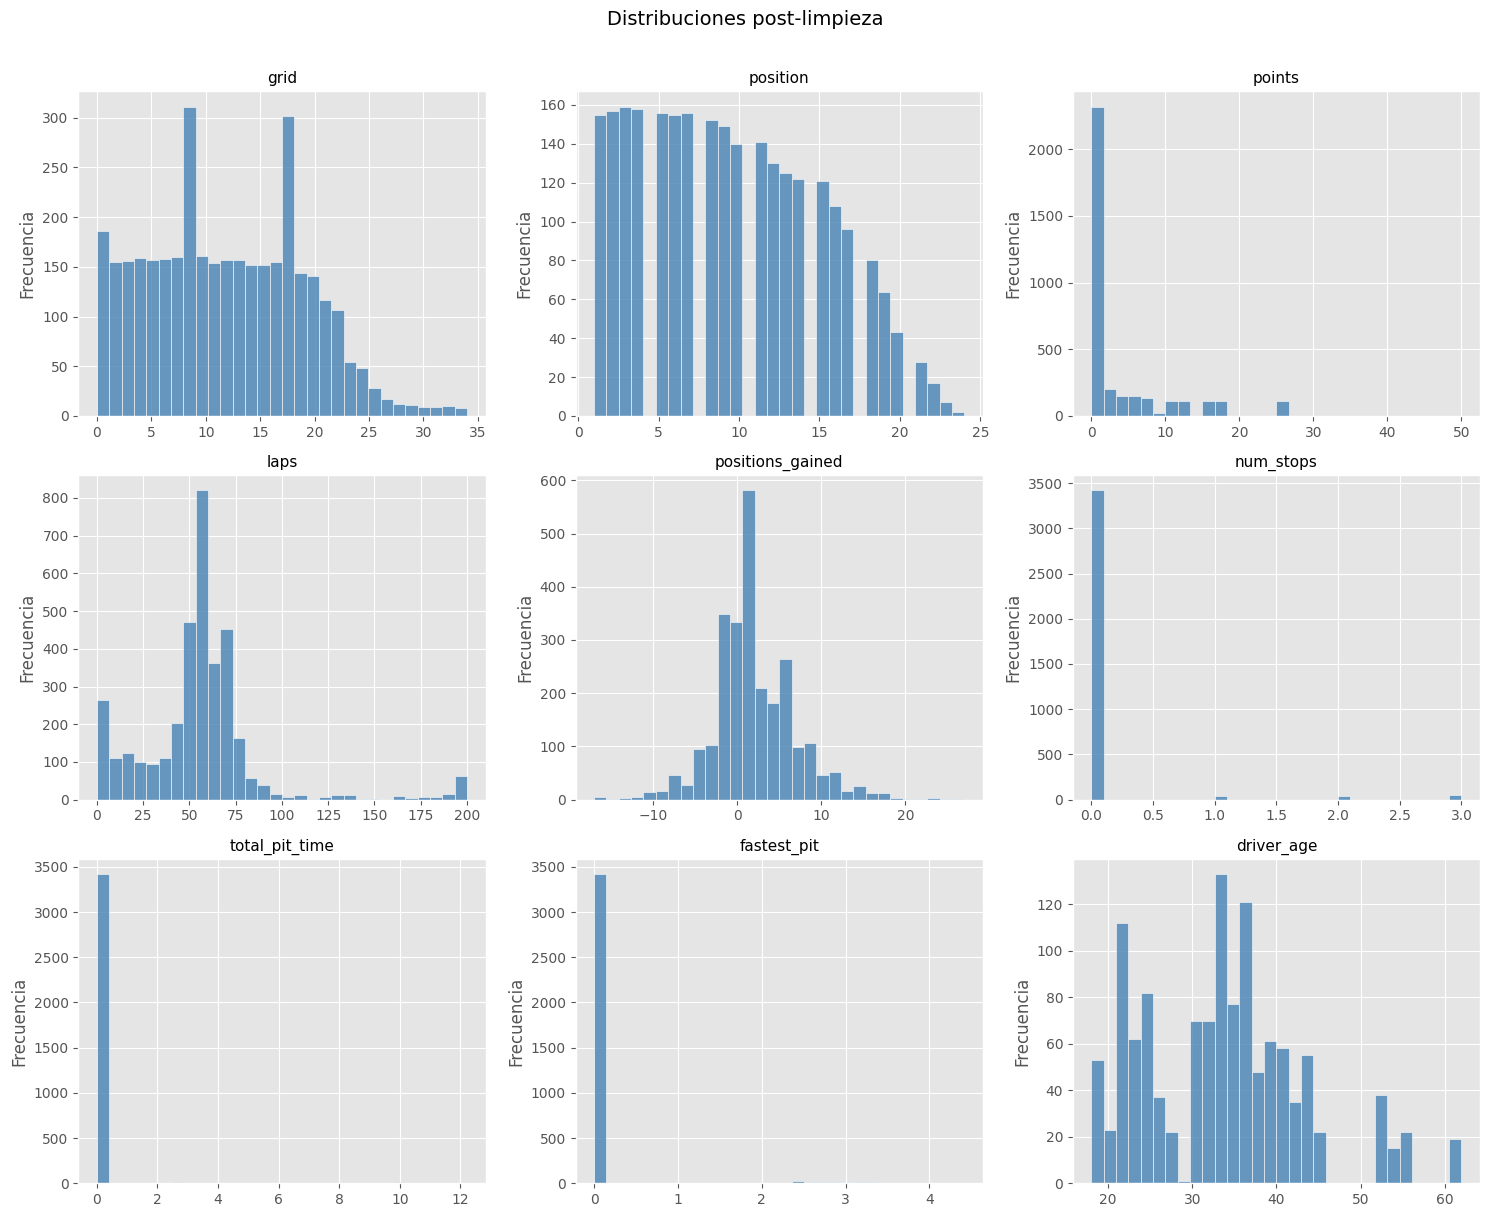

In [19]:
# Gráfico resumen: distribuciones de features principales post-limpieza
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features_num):
    data = df_clean[col].dropna()
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribuciones post-limpieza', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/03_distribuciones_limpias.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Exportar
import os
output_path = '../data/f1_master_clean.csv'
df_clean.to_csv(output_path, index=False)

size_kb = round(os.path.getsize(output_path) / 1024, 1)
print(f'✅ f1_master_clean.csv guardado en /data')
print(f'   Tamaño: {size_kb} KB')
print(f'   Shape:  {df_clean.shape[0]} filas × {df_clean.shape[1]} columnas')

✅ f1_master_clean.csv guardado en /data
   Tamaño: 652.7 KB
   Shape:  3547 filas × 36 columnas


---
## ✅ Resumen Semana 3

| Tarea | Estado |
|-------|--------|
| Diagnóstico completo de nulos | ✅ |
| Eliminar columnas >99% nulos (`fastestLap`, `fastestLapTime`) | ✅ |
| Imputar pit stops nulos con 0 | ✅ |
| Eliminar 8 filas sin info de carrera | ✅ |
| Normalizar fechas → `driver_age` | ✅ |
| Marcar `pit_lane_start` (grid = 0) | ✅ |
| Detección de outliers con IQR | ✅ |
| Flag `pit_time_outlier` para tiempos extremos | ✅ |
| Ranking de constructores `team_rank` | ✅ |
| `f1_master_clean.csv` exportado a `/data` | ✅ |

### Próximos pasos — Semana 4
- EDA profundo: correlaciones, distribuciones por equipo y circuito
- Visualizaciones: heatmap de correlación, violin plots por constructor
- Análisis de la variable objetivo `position` y `top3`
- Notebook `04_eda.ipynb`